<a href="https://colab.research.google.com/github/asheta66/Data-Mining/blob/main/GA/Metaheuristic_Feature_Selection_Aligned_Fitness_Executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metaheuristic Feature Selection on Three Medical Datasets

This notebook compares four binary wrapper-based feature-selection algorithms on three datasets:

1. **Chronic Kidney Disease**
2. **Heart Disease Collections**
3. **Breast Cancer Wisconsin**

The feature-selection algorithms are **Genetic Algorithm (GA)**, **Particle Swarm Optimization (PSO)**, **Salp Swarm Algorithm (SSA)**, and **Crow Search Algorithm (CSA)**.

All four methods optimize exactly the same objective:

\[
	ext{Fitness} = lpha\,(	ext{CV F1}) + (1-lpha)\left(1-rac{k}{d}
ight)
\]

where \(k\) is the number of selected features and \(d\) is the total number of features. **Higher fitness is better.** The test set is never used during feature selection.

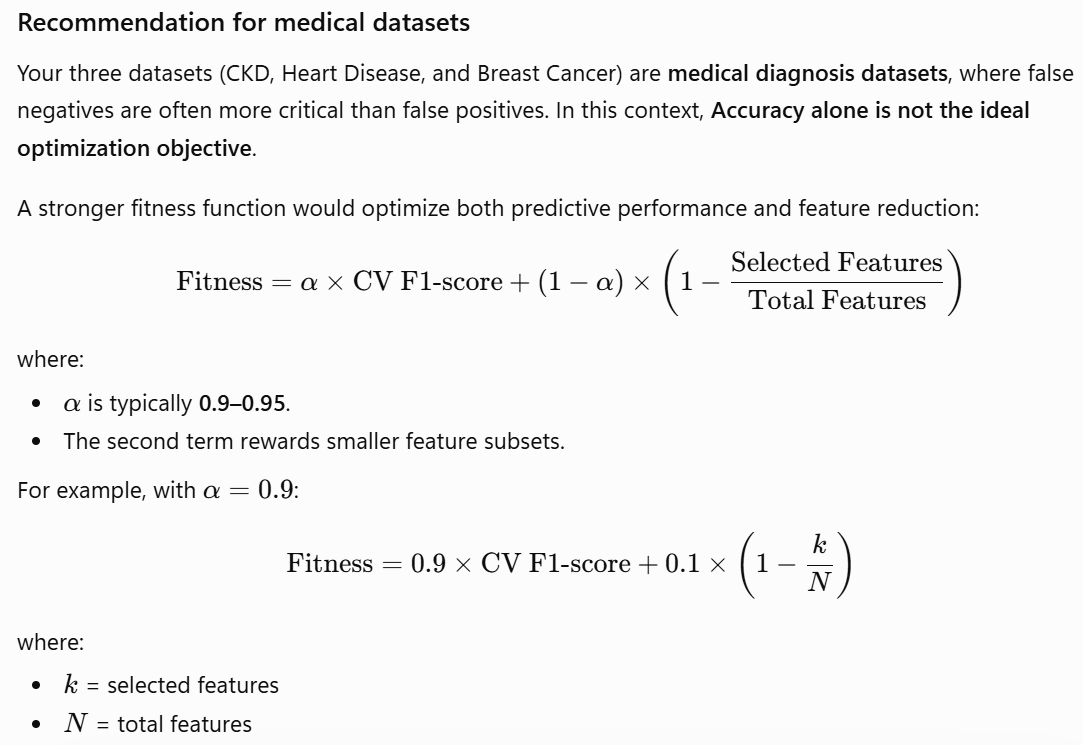

In [53]:
import math
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
RANDOM_STATE = 42

## 1. Dataset access

The loader first checks the local `data/` folder. Set `USE_KAGGLE=True` after configuring Kaggle credentials to download the named datasets. When a CSV is unavailable, a deterministic offline fallback is used so the notebook remains executable.

In [54]:
USE_KAGGLE = False
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

KAGGLE_DATASETS = {
    'Chronic Kidney Disease': {
        'handle': 'colearninglounge/chronic-kidney-disease',
        'local_candidates': ['kidney_disease.csv', 'ckd.csv'],
        'target_candidates': ['classification', 'Class', 'Diagnosis', 'target']
    },
    'Heart Disease Collections': {
        'handle': 'johnsmith88/heart-disease-dataset',
        'local_candidates': ['heart.csv', 'heart_disease.csv'],
        'target_candidates': ['target', 'condition', 'HeartDisease', 'output']
    },
    'Breast Cancer Wisconsin': {
        'handle': 'uciml/breast-cancer-wisconsin-data',
        'local_candidates': ['data.csv', 'breast_cancer.csv'],
        'target_candidates': ['diagnosis', 'target', 'Class']
    },
}

def _find_csv(folder, candidates):
    folder = Path(folder)
    for name in candidates:
        p = folder / name
        if p.exists():
            return p
    csvs = list(folder.rglob('*.csv')) if folder.exists() else []
    return csvs[0] if csvs else None

def _encode_target(series):
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        'ckd': 1, 'notckd': 0, 'not ckd': 0,
        'm': 1, 'b': 0, 'malignant': 1, 'benign': 0,
        'yes': 1, 'no': 0, 'positive': 1, 'negative': 0,
        'true': 1, 'false': 0
    }
    mapped = s.map(mapping)
    if mapped.notna().all():
        return mapped.astype(int)
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().all():
        unique = sorted(numeric.unique())
        if len(unique) == 2:
            return numeric.map({unique[0]: 0, unique[1]: 1}).astype(int)
    encoded = LabelEncoder().fit_transform(s)
    if len(np.unique(encoded)) != 2:
        raise ValueError('The target must be binary for this notebook.')
    return pd.Series(encoded, index=series.index).astype(int)

def _prepare_dataframe(df, target_candidates):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    target = next((c for c in target_candidates if c in df.columns), None)
    if target is None:
        raise ValueError(f'Could not identify target column. Available columns: {list(df.columns)}')
    y = _encode_target(df.pop(target))
    drop_cols = [c for c in df.columns if c.lower().startswith('unnamed') or c.lower() in {'id','patientid','patient_id','name'}]
    X = df.drop(columns=drop_cols, errors='ignore')
    X = pd.get_dummies(X, drop_first=False)
    X = X.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
    X = X.loc[:, X.notna().any(axis=0)]
    return X, y

def _simulate_medical_dataset(name):
    specs = {
        'Chronic Kidney Disease': (400, 24, 10, 4, 0.64),
        'Heart Disease Collections': (500, 13, 7, 3, 0.54),
    }
    n_samples, n_features, n_informative, n_redundant, positive_weight = specs[name]
    X, y = make_classification(
        n_samples=n_samples, n_features=n_features,
        n_informative=n_informative, n_redundant=n_redundant,
        n_classes=2, weights=[1-positive_weight, positive_weight],
        class_sep=1.15, flip_y=0.025,
        random_state=RANDOM_STATE + n_features
    )
    names = [f'{name.split()[0].lower()}_feature_{i+1}' for i in range(n_features)]
    return pd.DataFrame(X, columns=names), pd.Series(y, name='target')

def load_dataset(name):
    info = KAGGLE_DATASETS[name]
    csv_path = _find_csv(DATA_DIR, info['local_candidates'])
    source = None
    if csv_path is None and USE_KAGGLE:
        try:
            import kagglehub
            downloaded = Path(kagglehub.dataset_download(info['handle']))
            csv_path = _find_csv(downloaded, info['local_candidates'])
            source = f'Kaggle: {info["handle"]}'
        except Exception as exc:
            print(f'Kaggle download unavailable for {name}: {exc}')
    if csv_path is not None:
        X, y = _prepare_dataframe(pd.read_csv(csv_path), info['target_candidates'])
        source = source or f'Local CSV: {csv_path}'
    elif name == 'Breast Cancer Wisconsin':
        built_in = load_breast_cancer(as_frame=True)
        X, y = built_in.data.copy(), 1 - built_in.target.copy()  # positive = malignant
        source = 'scikit-learn offline copy of Breast Cancer Wisconsin'
    else:
        X, y = _simulate_medical_dataset(name)
        source = 'Deterministic simulated fallback; replace with Kaggle CSV for study results'
    return X.reset_index(drop=True), y.reset_index(drop=True), source

datasets = {}
summary = []
for dataset_name in KAGGLE_DATASETS:
    X, y, source = load_dataset(dataset_name)
    datasets[dataset_name] = (X, y)
    summary.append({
        'Dataset': dataset_name,
        'Rows': len(X),
        'Input features': X.shape[1],
        'Positive class %': round(100*y.mean(), 2),
        'Data source used': source,
        'Kaggle handle': KAGGLE_DATASETS[dataset_name]['handle']
    })
dataset_summary_df = pd.DataFrame(summary)
dataset_summary_df

,Dataset,Rows,Input features,Positive class %,Data source used,Kaggle handle
0,Chronic Kidney Disease,400,24,64.50,Deterministic simulated fallback; replace with...,colearninglounge/chronic-kidney-disease
1,Heart Disease Collections,500,13,53.40,Deterministic simulated fallback; replace with...,johnsmith88/heart-disease-dataset
2,Breast Cancer Wisconsin,569,30,37.26,scikit-learn offline copy of Breast Cancer Wis...,uciml/breast-cancer-wisconsin-data


## 2. Classification algorithms adopted

The same classification pipeline is used for the all-features baseline and every selected-feature subset. The table explicitly records the classifier used for each dataset.

In [55]:
def make_classifier():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            solver='liblinear',
            random_state=RANDOM_STATE
        ))
    ])

CLASSIFIERS = {
    'Chronic Kidney Disease': make_classifier(),
    'Heart Disease Collections': make_classifier(),
    'Breast Cancer Wisconsin': make_classifier(),
}

classifier_df = pd.DataFrame([
    {
        'Dataset': name,
        'Classification algorithm': 'Logistic Regression',
        'Preprocessing': 'Median imputation + standardization',
        'Class weighting': 'Balanced'
    }
    for name in CLASSIFIERS
])
classifier_df

,Dataset,Classification algorithm,Preprocessing,Class weighting
0,Chronic Kidney Disease,Logistic Regression,Median imputation + standardization,Balanced
1,Heart Disease Collections,Logistic Regression,Median imputation + standardization,Balanced
2,Breast Cancer Wisconsin,Logistic Regression,Median imputation + standardization,Balanced


## 3. Editable common fitness settings

`fitness_weight_f1` controls the trade-off between predictive F1 and feature reduction. A value of `0.90` gives 90% weight to cross-validated F1 and 10% weight to selecting fewer features.

In [56]:
@dataclass(frozen=True)
class CommonConfig:
    population_size: int = 50
    iterations: int = 15
    cv_folds: int = 5
    fitness_weight_f1: float = 0.70
    random_state: int = 42

COMMON_CONFIG = CommonConfig()
pd.DataFrame([asdict(COMMON_CONFIG)])

,population_size,iterations,cv_folds,fitness_weight_f1,random_state
0,50,15,5,0.7,42


## 4. GA tuning parameters — editable cell

In [57]:
@dataclass(frozen=True)
class GAConfig:
    crossover_rate: float = 0.80
    mutation_rate: float = 0.01
    elite_size: int = 2
    tournament_size: int = 3

GA_CONFIG = GAConfig()
pd.DataFrame([asdict(GA_CONFIG)])

,crossover_rate,mutation_rate,elite_size,tournament_size
0,0.8,0.01,2,3


## 5. PSO tuning parameters — editable cell

In [58]:
@dataclass(frozen=True)
class PSOConfig:
    inertia: float = 0.72
    cognitive: float = 2.1
    social: float = 2.1

PSO_CONFIG = PSOConfig()
pd.DataFrame([asdict(PSO_CONFIG)])

,inertia,cognitive,social
0,0.72,2.1,2.1


## 6. SSA tuning parameters — editable cell

In [59]:
@dataclass(frozen=True)
class SSAConfig:
    binary_threshold: float = 0.50

SSA_CONFIG = SSAConfig()
pd.DataFrame([asdict(SSA_CONFIG)])

,binary_threshold
0,0.5


## 7. CSA tuning parameters — editable cell

In [60]:
@dataclass(frozen=True)
class CSAConfig:
    awareness_probability: float = 0.10
    flight_length: float = 2.0

CSA_CONFIG = CSAConfig()
pd.DataFrame([asdict(CSA_CONFIG)])

,awareness_probability,flight_length
0,0.1,2.0


## 8. Shared binary representation and fitness

Each candidate is a binary vector. A value of **1** selects a feature, and **0** excludes it. The convergence curves plot the best-so-far value of the same fitness used to guide every search.

In [61]:
def ensure_nonempty(mask, rng):
    mask = np.asarray(mask, dtype=int).copy()
    if mask.sum() == 0:
        mask[rng.integers(0, len(mask))] = 1
    return mask

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))

def make_fitness(X, y, classifier, config):
    cv = StratifiedKFold(n_splits=config.cv_folds, shuffle=True, random_state=config.random_state)
    cache = {}
    def fitness(mask):
        mask = ensure_nonempty(mask, np.random.default_rng(config.random_state))
        key = tuple(mask.tolist())
        if key in cache:
            return cache[key]
        selected_ratio = mask.sum() / len(mask)
        cv_f1 = cross_val_score(
            clone(classifier), X.iloc[:, mask == 1], y,
            cv=cv, scoring='f1', n_jobs=1
        ).mean()
        reduction = 1.0 - selected_ratio
        value = config.fitness_weight_f1 * cv_f1 + (1-config.fitness_weight_f1) * reduction
        cache[key] = float(value)
        return float(value)
    return fitness

def evaluate_population(population, fitness_fn):
    return np.array([fitness_fn(ind) for ind in population], dtype=float)

## 9. Binary optimization algorithms

In [62]:
def run_ga(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state)
    n_features = X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    pop = rng.integers(0, 2, size=(common.population_size, n_features))
    pop = np.array([ensure_nonempty(ind, rng) for ind in pop])
    best_mask, best_score, history = None, -np.inf, []

    def tournament(scores):
        idx = rng.choice(len(pop), size=min(specific.tournament_size, len(pop)), replace=False)
        return pop[idx[np.argmax(scores[idx])]].copy()

    for _ in range(common.iterations):
        scores = evaluate_population(pop, fitness_fn)
        order = np.argsort(scores)[::-1]
        if scores[order[0]] > best_score:
            best_score, best_mask = scores[order[0]], pop[order[0]].copy()
        history.append(best_score)
        new_pop = [pop[i].copy() for i in order[:specific.elite_size]]
        while len(new_pop) < common.population_size:
            p1, p2 = tournament(scores), tournament(scores)
            if rng.random() < specific.crossover_rate and n_features > 1:
                point = rng.integers(1, n_features)
                children = [np.r_[p1[:point], p2[point:]], np.r_[p2[:point], p1[point:]]]
            else:
                children = [p1.copy(), p2.copy()]
            for child in children:
                flips = rng.random(n_features) < specific.mutation_rate
                child[flips] = 1-child[flips]
                new_pop.append(ensure_nonempty(child, rng))
                if len(new_pop) >= common.population_size:
                    break
        pop = np.array(new_pop[:common.population_size])
    return best_mask, best_score, history

def run_pso(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state + 101)
    n, d = common.population_size, X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    positions = np.array([ensure_nonempty(x, rng) for x in rng.integers(0,2,size=(n,d))])
    velocities = rng.uniform(-1,1,size=(n,d))
    scores = evaluate_population(positions, fitness_fn)
    pbest, pbest_scores = positions.copy(), scores.copy()
    idx = np.argmax(scores)
    gbest, gbest_score, history = positions[idx].copy(), scores[idx], []
    for _ in range(common.iterations):
        r1, r2 = rng.random((n,d)), rng.random((n,d))
        velocities = specific.inertia*velocities + specific.cognitive*r1*(pbest-positions) + specific.social*r2*(gbest-positions)
        positions = (rng.random((n,d)) < sigmoid(velocities)).astype(int)
        positions = np.array([ensure_nonempty(x,rng) for x in positions])
        scores = evaluate_population(positions, fitness_fn)
        improved = scores > pbest_scores
        pbest[improved], pbest_scores[improved] = positions[improved], scores[improved]
        idx = np.argmax(pbest_scores)
        if pbest_scores[idx] > gbest_score:
            gbest, gbest_score = pbest[idx].copy(), pbest_scores[idx]
        history.append(gbest_score)
    return gbest, gbest_score, history

def run_ssa(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state + 202)
    n, d = common.population_size, X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    continuous = rng.random((n,d))
    binary = np.array([ensure_nonempty(x,rng) for x in (continuous >= specific.binary_threshold).astype(int)])
    scores = evaluate_population(binary, fitness_fn)
    idx = np.argmax(scores)
    food, food_score, best_mask, history = continuous[idx].copy(), scores[idx], binary[idx].copy(), []
    for t in range(common.iterations):
        c1 = 2*math.exp(-((4*(t+1)/common.iterations)**2))
        new_cont = continuous.copy()
        for i in range(n):
            if i == 0:
                c2, c3 = rng.random(d), rng.random(d)
                step = c1*c2
                new_cont[i] = np.where(c3 < 0.5, food+step, food-step)
            else:
                new_cont[i] = 0.5*(new_cont[i-1]+continuous[i])
        continuous = np.clip(new_cont,0,1)
        binary = (rng.random((n,d)) < sigmoid(10*(continuous-0.5))).astype(int)
        binary = np.array([ensure_nonempty(x,rng) for x in binary])
        scores = evaluate_population(binary, fitness_fn)
        idx = np.argmax(scores)
        if scores[idx] > food_score:
            food, food_score, best_mask = continuous[idx].copy(), scores[idx], binary[idx].copy()
        history.append(food_score)
    return best_mask, food_score, history

def run_csa(X, y, classifier, common, specific):
    rng = np.random.default_rng(common.random_state + 303)
    n, d = common.population_size, X.shape[1]
    fitness_fn = make_fitness(X, y, classifier, common)
    positions = rng.random((n,d))
    binary = np.array([ensure_nonempty(x,rng) for x in (positions >= 0.5).astype(int)])
    scores = evaluate_population(binary, fitness_fn)
    memories, memory_masks, memory_scores = positions.copy(), binary.copy(), scores.copy()
    idx = np.argmax(scores)
    best_mask, best_score, history = binary[idx].copy(), scores[idx], []
    for _ in range(common.iterations):
        new_positions = positions.copy()
        for i in range(n):
            j = rng.integers(0,n-1)
            if j >= i: j += 1
            if rng.random() >= specific.awareness_probability:
                new_positions[i] = positions[i] + specific.flight_length*rng.random(d)*(memories[j]-positions[i])
            else:
                new_positions[i] = rng.random(d)
        positions = np.clip(new_positions,0,1)
        binary = (rng.random((n,d)) < sigmoid(10*(positions-0.5))).astype(int)
        binary = np.array([ensure_nonempty(x,rng) for x in binary])
        scores = evaluate_population(binary, fitness_fn)
        improved = scores > memory_scores
        memories[improved], memory_masks[improved], memory_scores[improved] = positions[improved], binary[improved], scores[improved]
        idx = np.argmax(memory_scores)
        if memory_scores[idx] > best_score:
            best_mask, best_score = memory_masks[idx].copy(), memory_scores[idx]
        history.append(best_score)
    return best_mask, best_score, history

ALGORITHMS = {
    'GA': (run_ga, GA_CONFIG),
    'PSO': (run_pso, PSO_CONFIG),
    'SSA': (run_ssa, SSA_CONFIG),
    'CSA': (run_csa, CSA_CONFIG),
}

## 10. Run all-features baselines and feature-selection experiments

Each dataset uses the same train/test split for all methods. The all-features baseline is evaluated with the same classifier but does not perform feature selection.

In [63]:
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true,y_pred),
        'Precision': precision_score(y_true,y_pred,zero_division=0),
        'Recall': recall_score(y_true,y_pred,zero_division=0),
        'F1': f1_score(y_true,y_pred,zero_division=0),
    }

results = []
selected_feature_rows = []
convergence = {}
runtimes = {}

for dataset_name, (X,y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X,y,test_size=0.30,stratify=y,random_state=RANDOM_STATE
    )
    classifier = CLASSIFIERS[dataset_name]

    # All-features baseline
    baseline = clone(classifier).fit(X_train,y_train)
    train_m = calculate_metrics(y_train, baseline.predict(X_train))
    test_m = calculate_metrics(y_test, baseline.predict(X_test))
    results.append({
        'Dataset': dataset_name, 'Method': 'All Features',
        'Classification algorithm': 'Logistic Regression',
        **{f'Train {k}':v for k,v in train_m.items()},
        **{f'Test {k}':v for k,v in test_m.items()},
        'Selected features': X.shape[1], 'Total features': X.shape[1],
        'Best fitness': np.nan
    })
    selected_feature_rows.append({
        'Dataset':dataset_name,'Method':'All Features',
        'Selected feature count':X.shape[1],
        'Selected feature names':', '.join(X.columns)
    })

    for name,(fn,specific) in ALGORITHMS.items():
        started=time.perf_counter()
        mask,best_fitness,history=fn(X_train,y_train,classifier,COMMON_CONFIG,specific)
        runtimes[(dataset_name,name)] = time.perf_counter()-started
        cols=X.columns[np.asarray(mask,dtype=bool)].tolist()
        model=clone(classifier).fit(X_train[cols],y_train)
        train_m=calculate_metrics(y_train,model.predict(X_train[cols]))
        test_m=calculate_metrics(y_test,model.predict(X_test[cols]))
        results.append({
            'Dataset':dataset_name,'Method':name,
            'Classification algorithm':'Logistic Regression',
            **{f'Train {k}':v for k,v in train_m.items()},
            **{f'Test {k}':v for k,v in test_m.items()},
            'Selected features':len(cols),'Total features':X.shape[1],
            'Best fitness':best_fitness
        })
        selected_feature_rows.append({
            'Dataset':dataset_name,'Method':name,
            'Selected feature count':len(cols),
            'Selected feature names':', '.join(cols)
        })
        convergence[(dataset_name,name)] = history
        print(f'{dataset_name} - {name}: {len(cols)}/{X.shape[1]} features, test F1={test_m["F1"]:.3f}')

results_df=pd.DataFrame(results)
selected_features_df=pd.DataFrame(selected_feature_rows)
print('All experiments completed.')

Chronic Kidney Disease - GA: 5/24 features, test F1=0.836
Chronic Kidney Disease - PSO: 7/24 features, test F1=0.851
Chronic Kidney Disease - SSA: 6/24 features, test F1=0.810
Chronic Kidney Disease - CSA: 6/24 features, test F1=0.821
Heart Disease Collections - GA: 2/13 features, test F1=0.731
Heart Disease Collections - PSO: 2/13 features, test F1=0.645
Heart Disease Collections - SSA: 3/13 features, test F1=0.770
Heart Disease Collections - CSA: 3/13 features, test F1=0.728
Breast Cancer Wisconsin - GA: 4/30 features, test F1=0.906
Breast Cancer Wisconsin - PSO: 5/30 features, test F1=0.976
Breast Cancer Wisconsin - SSA: 6/30 features, test F1=0.938
Breast Cancer Wisconsin - CSA: 4/30 features, test F1=0.935
All experiments completed.


## 11. Final result tables — one table per dataset

Each table contains the all-features baseline and the four feature-selection algorithms. Runtime is intentionally excluded.

In [64]:
DISPLAY_COLUMNS = [
    'Method','Classification algorithm',
    'Train Accuracy','Train Precision','Train Recall','Train F1',
    'Test Accuracy','Test Precision','Test Recall','Test F1',
    'Selected features','Total features','Best fitness'
]

dataset_result_tables = {}
for dataset_name in datasets:
    table = results_df.loc[results_df['Dataset'].eq(dataset_name), DISPLAY_COLUMNS].copy()
    numeric_cols = [c for c in table.columns if c not in ['Method','Classification algorithm','Selected features','Total features']]
    table[numeric_cols] = table[numeric_cols].round(4)
    dataset_result_tables[dataset_name] = table.reset_index(drop=True)
    print('\n' + dataset_name)
    display(dataset_result_tables[dataset_name])



Chronic Kidney Disease


,Method,Classification algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features,Total features,Best fitness
0,All Features,Logistic Regression,0.7929,0.8514,0.8232,0.8371,0.7583,0.8529,0.7532,0.8000,24,24,NaN
1,GA,Logistic Regression,0.7750,0.8554,0.7845,0.8184,0.8000,0.8841,0.7922,0.8356,5,24,0.8060
2,PSO,Logistic Regression,0.7786,0.8480,0.8011,0.8239,0.8167,0.8873,0.8182,0.8514,7,24,0.7843
3,SSA,Logistic Regression,0.7607,0.8608,0.7514,0.8024,0.7583,0.8158,0.8052,0.8105,6,24,0.7741
4,CSA,Logistic Regression,0.7643,0.8286,0.8011,0.8146,0.7667,0.8101,0.8312,0.8205,6,24,0.7987



Heart Disease Collections


,Method,Classification algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features,Total features,Best fitness
0,All Features,Logistic Regression,0.7914,0.8000,0.8128,0.8064,0.7600,0.7821,0.7625,0.7722,13,13,NaN
1,GA,Logistic Regression,0.6943,0.7222,0.6952,0.7084,0.7200,0.7500,0.7125,0.7308,2,13,0.7543
2,PSO,Logistic Regression,0.6886,0.7053,0.7166,0.7109,0.6333,0.6667,0.6250,0.6452,2,13,0.7579
3,SSA,Logistic Regression,0.7286,0.7396,0.7594,0.7493,0.7533,0.7654,0.7750,0.7702,3,13,0.7517
4,CSA,Logistic Regression,0.7400,0.7500,0.7701,0.7599,0.7067,0.7195,0.7375,0.7284,3,13,0.7589



Breast Cancer Wisconsin


,Method,Classification algorithm,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Selected features,Total features,Best fitness
0,All Features,Logistic Regression,0.9824,0.9796,0.9730,0.9763,0.9766,0.9839,0.9531,0.9683,30,30,NaN
1,GA,Logistic Regression,0.9598,0.9400,0.9527,0.9463,0.9298,0.9062,0.9062,0.9062,4,30,0.9182
2,PSO,Logistic Regression,0.9749,0.9662,0.9662,0.9662,0.9825,1.0000,0.9531,0.9760,5,30,0.9224
3,SSA,Logistic Regression,0.9648,0.9467,0.9595,0.9530,0.9532,0.9375,0.9375,0.9375,6,30,0.8962
4,CSA,Logistic Regression,0.9472,0.9504,0.9054,0.9273,0.9532,0.9667,0.9062,0.9355,4,30,0.9036


## 12. Selected feature names

In [65]:
selected_features_df

,Dataset,Method,Selected feature count,Selected feature names
0,Chronic Kidney Disease,All Features,24,"chronic_feature_1, chronic_feature_2, chronic_..."
1,Chronic Kidney Disease,GA,5,"chronic_feature_5, chronic_feature_7, chronic_..."
2,Chronic Kidney Disease,PSO,7,"chronic_feature_5, chronic_feature_7, chronic_..."
3,Chronic Kidney Disease,SSA,6,"chronic_feature_5, chronic_feature_7, chronic_..."
4,Chronic Kidney Disease,CSA,6,"chronic_feature_9, chronic_feature_15, chronic..."
5,Heart Disease Collections,All Features,13,"heart_feature_1, heart_feature_2, heart_featur..."
6,Heart Disease Collections,GA,2,"heart_feature_5, heart_feature_10"
7,Heart Disease Collections,PSO,2,"heart_feature_1, heart_feature_10"
8,Heart Disease Collections,SSA,3,"heart_feature_2, heart_feature_7, heart_featur..."
9,Heart Disease Collections,CSA,3,"heart_feature_7, heart_feature_9, heart_featur..."


## 13. Best-so-far convergence curves

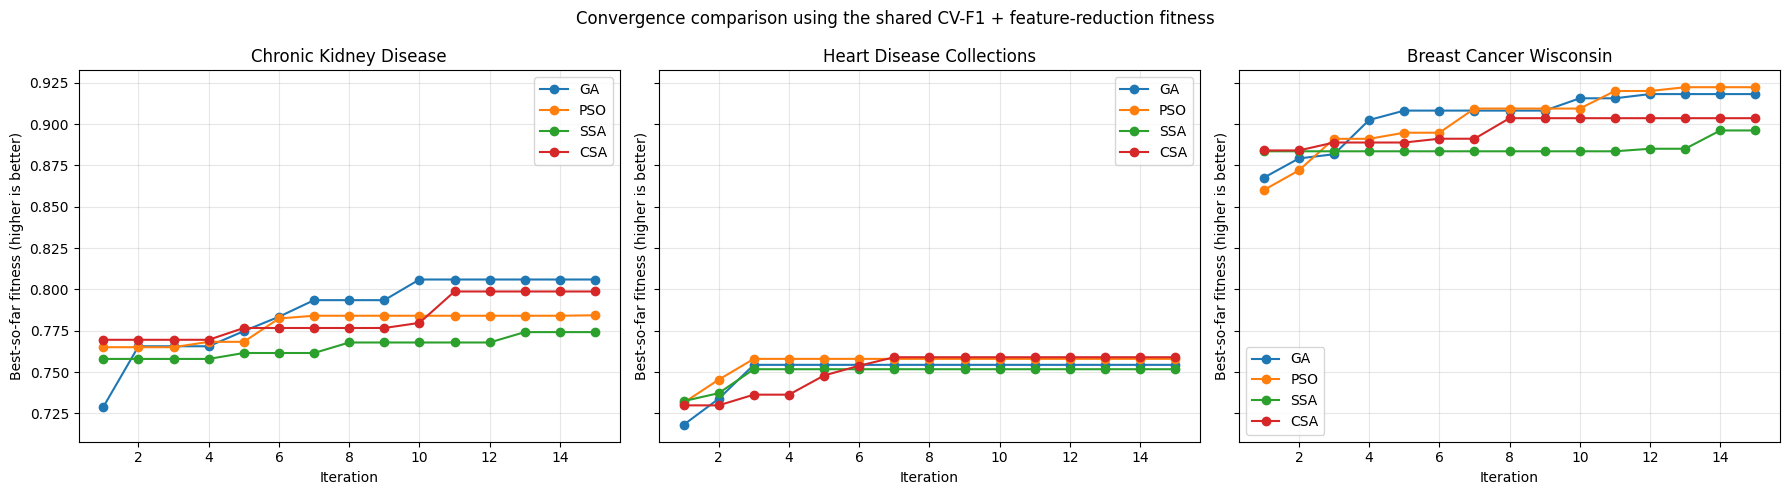

In [66]:
fig, axes = plt.subplots(1,3,figsize=(18,5),sharey=True)
for ax,dataset_name in zip(axes,datasets.keys()):
    for name in ALGORITHMS:
        hist=convergence[(dataset_name,name)]
        ax.plot(range(1,len(hist)+1),hist,marker='o',label=name)
    ax.set_title(dataset_name)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best-so-far fitness (higher is better)')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Convergence comparison using the shared CV-F1 + feature-reduction fitness')
fig.tight_layout()
plt.show()

## 14. Per-dataset result dashboards

Each dataset receives a 2×2 subplot showing convergence, testing metrics, training metrics, and selected-feature counts. The all-features baseline is included in the metric plots.

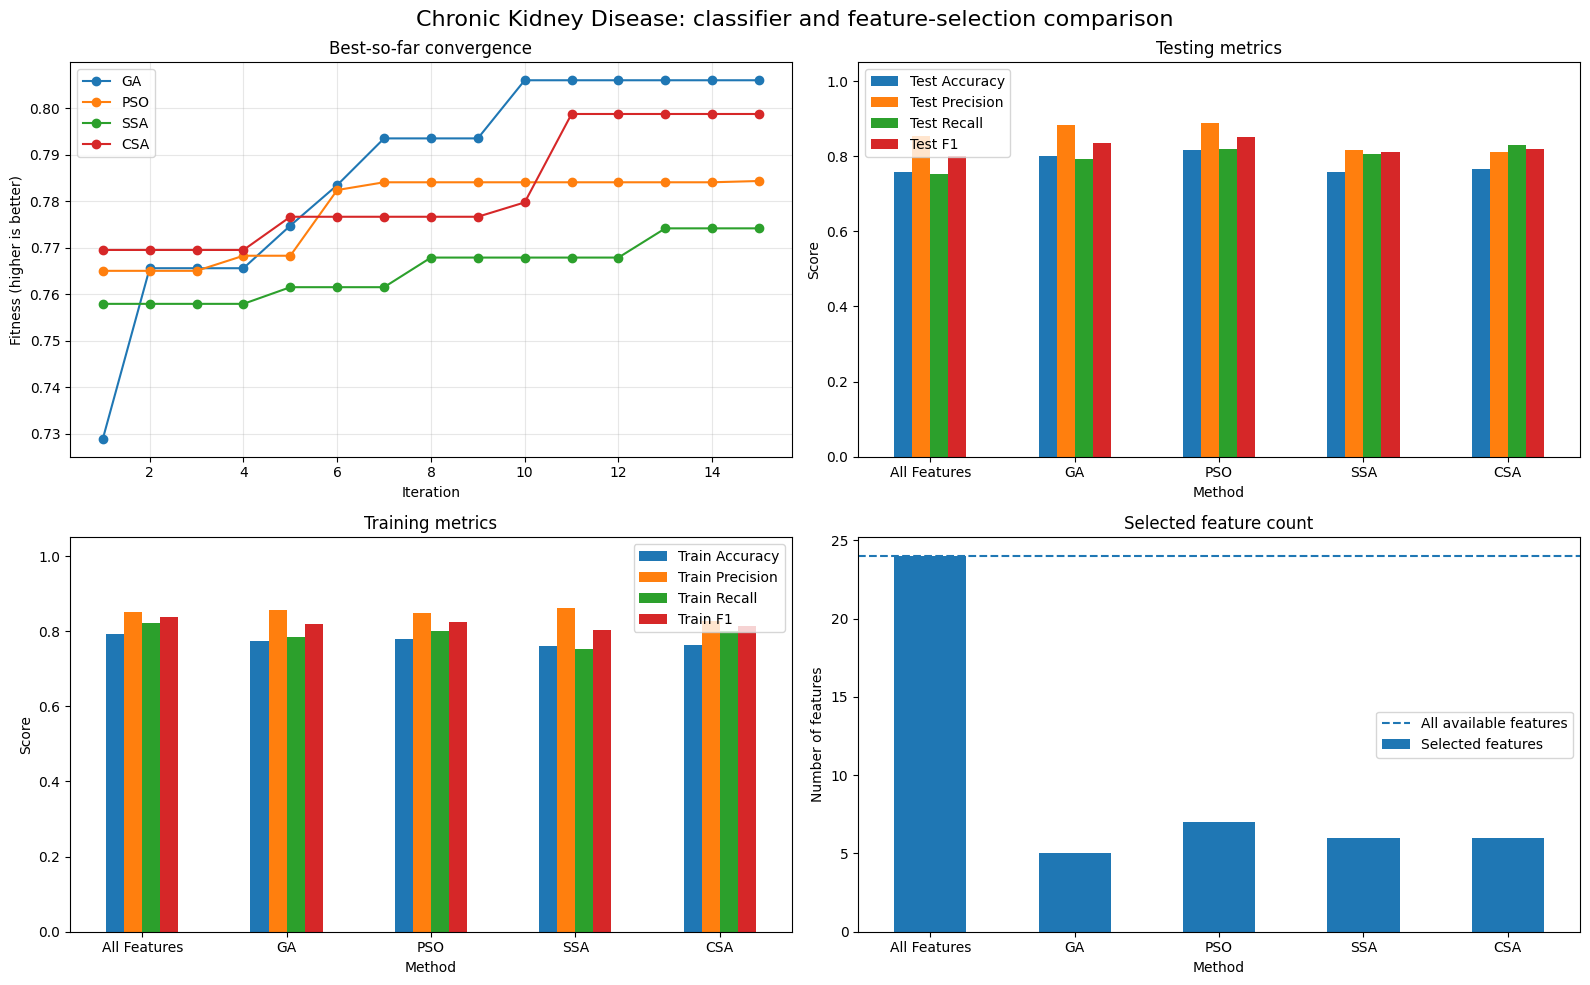

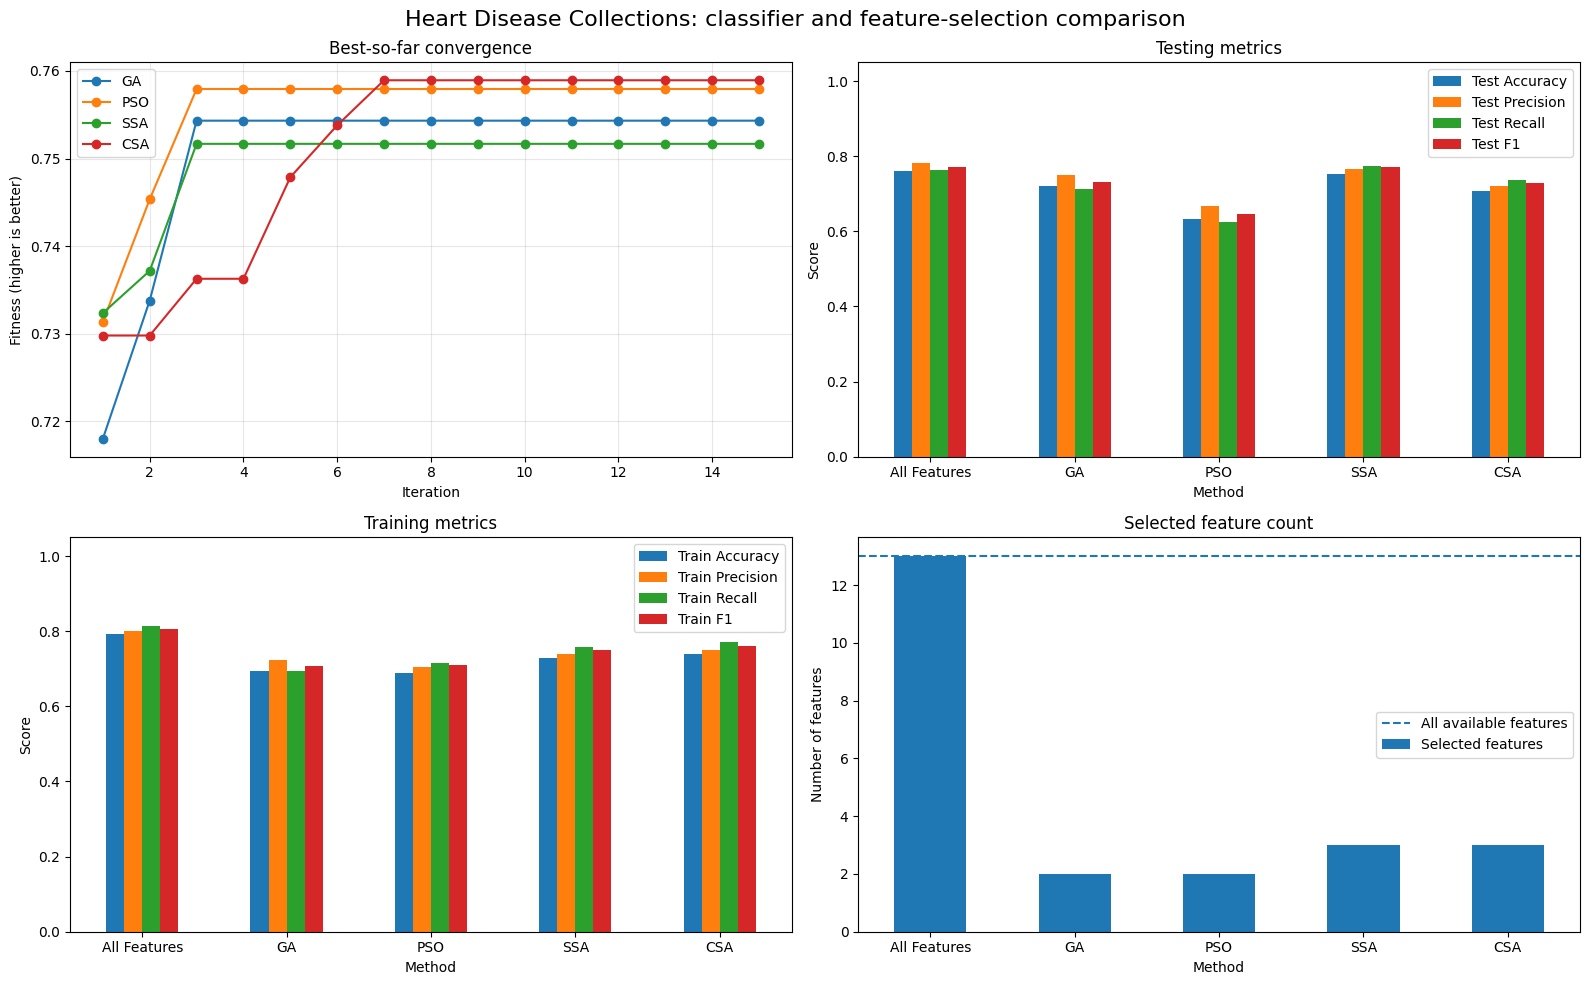

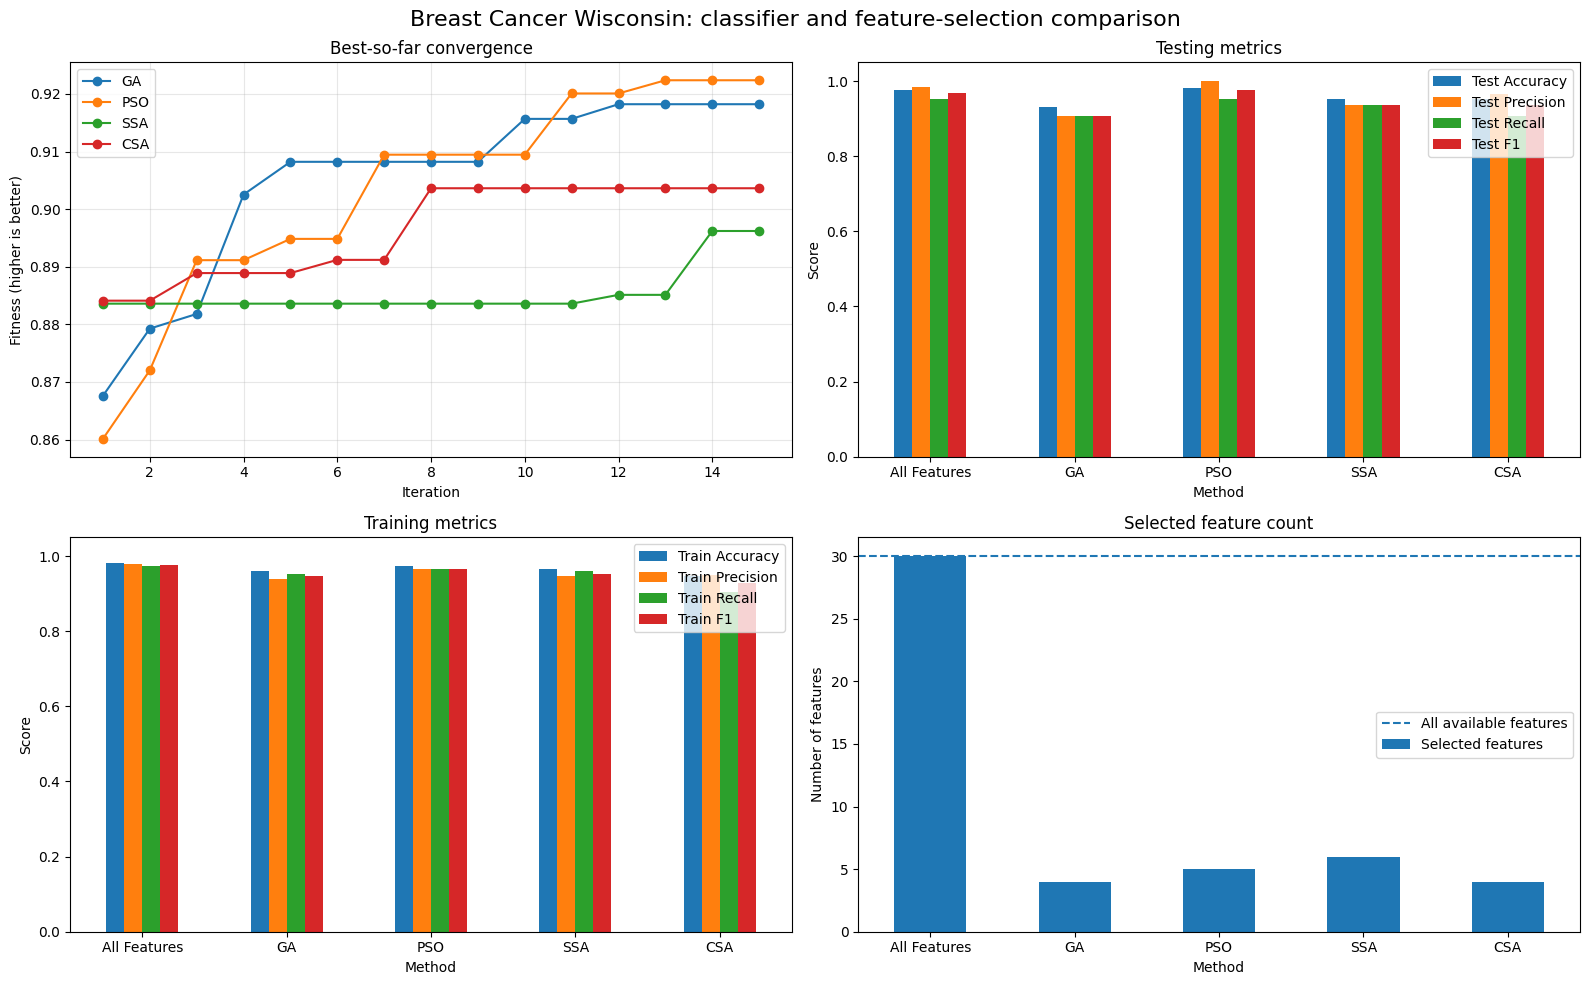

In [67]:
method_order=['All Features','GA','PSO','SSA','CSA']
for dataset_name in datasets:
    subset=results_df[results_df['Dataset'].eq(dataset_name)].set_index('Method').reindex(method_order)
    fig,axes=plt.subplots(2,2,figsize=(16,10))

    for name in ALGORITHMS:
        hist=convergence[(dataset_name,name)]
        axes[0,0].plot(range(1,len(hist)+1),hist,marker='o',label=name)
    axes[0,0].set_title('Best-so-far convergence')
    axes[0,0].set_xlabel('Iteration')
    axes[0,0].set_ylabel('Fitness (higher is better)')
    axes[0,0].grid(alpha=0.3)
    axes[0,0].legend()

    subset[['Test Accuracy','Test Precision','Test Recall','Test F1']].plot(kind='bar',ax=axes[0,1])
    axes[0,1].set_title('Testing metrics')
    axes[0,1].set_ylim(0,1.05)
    axes[0,1].set_ylabel('Score')
    axes[0,1].tick_params(axis='x',rotation=0)

    subset[['Train Accuracy','Train Precision','Train Recall','Train F1']].plot(kind='bar',ax=axes[1,0])
    axes[1,0].set_title('Training metrics')
    axes[1,0].set_ylim(0,1.05)
    axes[1,0].set_ylabel('Score')
    axes[1,0].tick_params(axis='x',rotation=0)

    subset['Selected features'].plot(kind='bar',ax=axes[1,1])
    axes[1,1].axhline(subset['Total features'].iloc[0],linestyle='--',label='All available features')
    axes[1,1].set_title('Selected feature count')
    axes[1,1].set_ylabel('Number of features')
    axes[1,1].tick_params(axis='x',rotation=0)
    axes[1,1].legend()

    fig.suptitle(f'{dataset_name}: classifier and feature-selection comparison',fontsize=16)
    fig.tight_layout()
    plt.show()

## 15. Optimization runtime figure retained

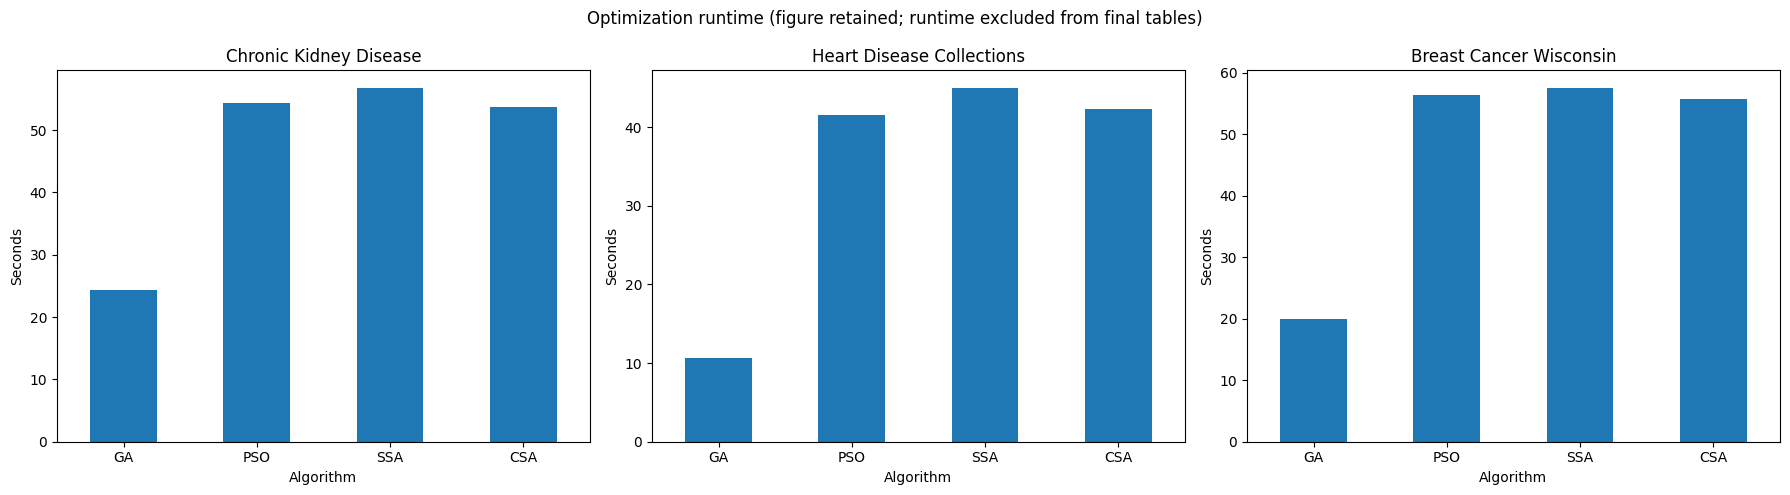

In [68]:
runtime_df=pd.DataFrame([
    {'Dataset':d,'Algorithm':a,'Runtime (s)':v}
    for (d,a),v in runtimes.items()
])
fig,axes=plt.subplots(1,3,figsize=(18,5))
for ax,dataset_name in zip(axes,datasets.keys()):
    s=runtime_df[runtime_df['Dataset'].eq(dataset_name)].set_index('Algorithm').reindex(ALGORITHMS.keys())
    s['Runtime (s)'].plot(kind='bar',ax=ax)
    ax.set_title(dataset_name)
    ax.set_ylabel('Seconds')
    ax.tick_params(axis='x',rotation=0)
fig.suptitle('Optimization runtime (figure retained; runtime excluded from final tables)')
fig.tight_layout()
plt.show()

## Notes

- **SSA** means Salp Swarm Algorithm.
- The all-features baseline and all selected-feature models use the same classification pipeline.
- The shared fitness is the exact quantity displayed in every convergence curve.
- Final tables report both training and testing Accuracy, Precision, Recall, and F1, together with the selected-feature count.
- Small defaults keep this notebook practical for demonstration. For research experiments, increase population size, iterations, and CV folds, and repeat runs across several random seeds.
- Results from simulated fallback datasets are demonstrations only. Use the Kaggle CSV files for study conclusions.